# EDA: ESC-10 and Speech Commands

In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import *

## Size and classes

In [2]:
for name in ['esc10', 'sc']:
    X, y, group = load_dataset(name)
    print(name, X.shape, 'clip length', X.shape[1] / SR, 's')
    print(pd.Series(group).value_counts().to_dict())
    print(np.bincount(y))

esc10 (400, 80000) clip length 5.0 s
{1: 80, 2: 80, 3: 80, 4: 80, 5: 80}
[40 40 40 40 40 40 40 40 40 40]
sc (38546, 16000) clip length 1.0 s
{'train': 30769, 'test': 4074, 'val': 3703}
[4044 3941 3723 3917 3801 3778 3845 3745 3872 3880]


## One clip per class: waveform and log-mel

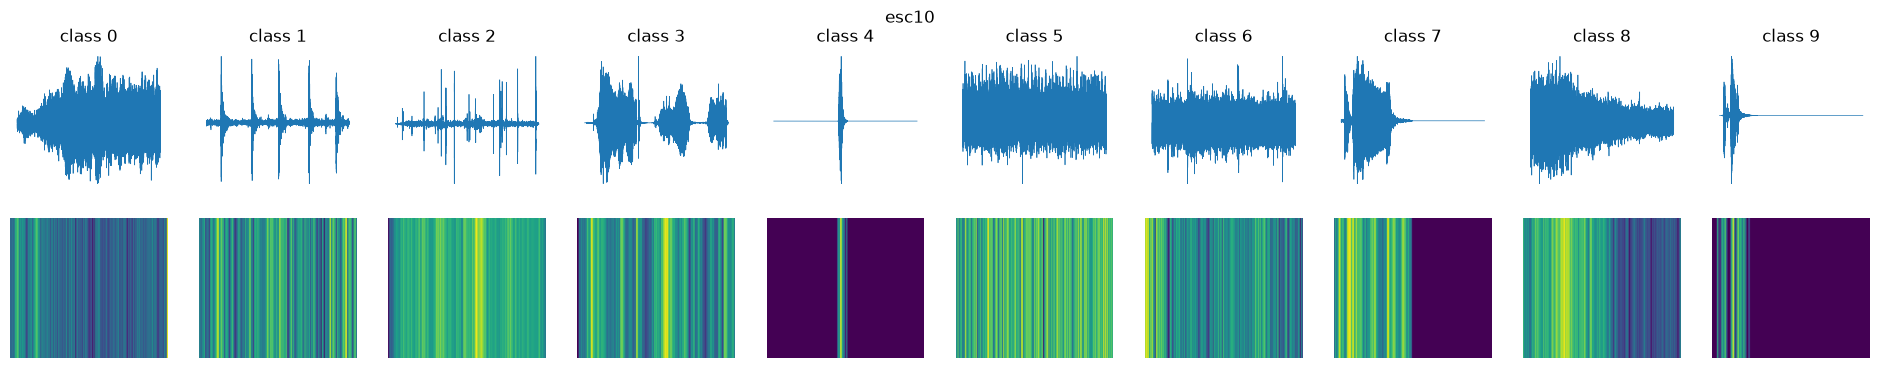

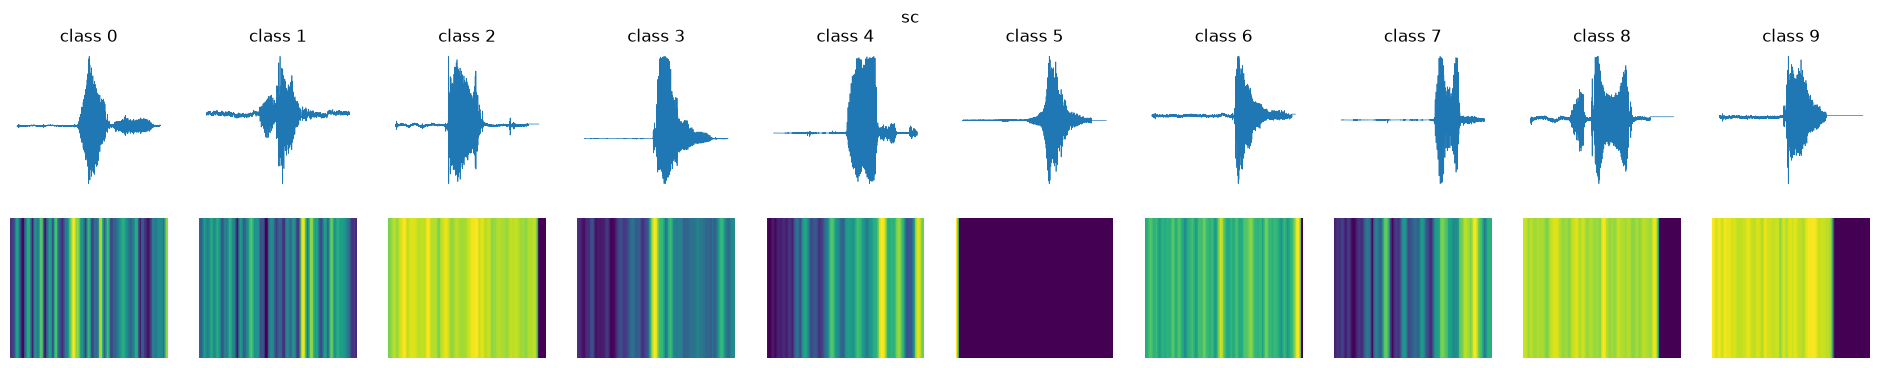

In [3]:
logmel = LogMel()
import torch
for name in ['esc10', 'sc']:
    X, y, _ = load_dataset(name)
    fig, axes = plt.subplots(2, 10, figsize=(24, 4))
    for c in range(10):
        x = np.array(X[np.where(y == c)[0][0]])
        axes[0, c].plot(x, linewidth=0.5); axes[0, c].set_title(f'class {c}'); axes[0, c].axis('off')
        axes[1, c].imshow(logmel(torch.from_numpy(x))[0].numpy(), origin='lower', aspect='auto'); axes[1, c].axis('off')
    plt.suptitle(name); plt.show()

## What the noise does to a clip (log-mel at each SNR)

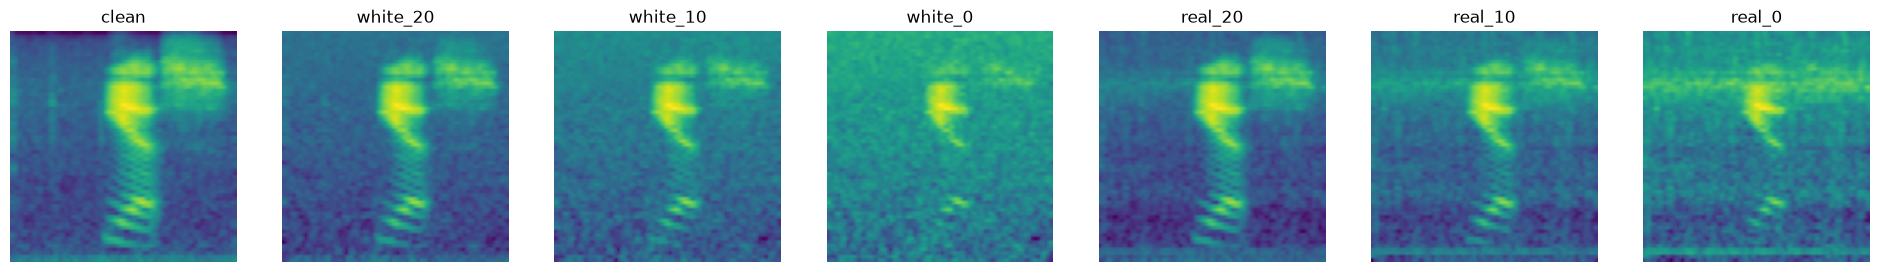

In [4]:
X, y, _ = load_dataset('sc')
clip = np.array(X[:1])
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(24, 3))
for ax, condition in zip(axes, CONDITIONS):
    ax.imshow(logmel(torch.from_numpy(apply_condition(clip, condition)))[0, 0].numpy(), origin='lower', aspect='auto')
    ax.set_title(condition); ax.axis('off')
plt.show()